
#ASSIGNMENT 7
###Creating and Fixing Mode Collapse in a GAN



1. Import Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


2. Setting Parameters

In [3]:
# Hyperparameters
batch_size = 128
image_size = 64
nz = 100
num_epochs = 20
lr = 0.0002

# Dataset
channels = 1

# Reproducibility
torch.manual_seed(42)

print("Batch size:", batch_size)
print("Epochs:", num_epochs)
print("Device:", device)

Batch size: 128
Epochs: 20
Device: cuda


3. Loading MNIST Dataset

In [4]:
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Dataset size:", len(dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]

Dataset size: 60000


4. Display Sample Images

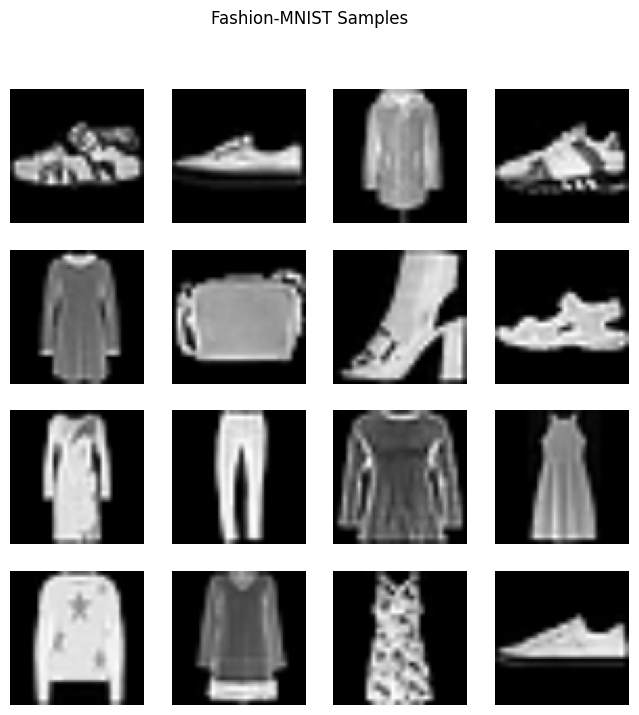

In [5]:
images, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("Fashion-MNIST Samples")
plt.show()

5. Define Weight Initialization


In [6]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)




6. Define Generator and Discriminator

In [7]:
class Generator(nn.Module):

    def __init__(self, nz=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 x 1 x 1 -> 512 x 4 x 4
            nn.ConvTranspose2d(nz, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 512 x 4 x 4 -> 256 x 8 x 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 8 x 8 -> 128 x 16 x 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 16 x 16 -> 64 x 32 x 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 32 x 32 -> 1 x 64 x 64
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 1 x 64 x 64 -> 64 x 32 x 32
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32 -> 128 x 16 x 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16 -> 256 x 8 x 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 x 8 x 8 -> 512 x 4 x 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 512 x 4 x 4 -> 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

7. Create a normal DCGAN

In [8]:
netG = Generator(nz).to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

8. Loss Function and Optimizers

In [9]:
criterion = nn.BCELoss()

optimizerD = optim.Adam(
    netD.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizerG = optim.Adam(
    netG.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Fixed noise for visual comparison
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

9. Function to display generated images

In [10]:
def show_generated_images(generator, epoch, title):

    with torch.no_grad():
        fake_images = generator(fixed_noise).detach().cpu()

    fake_images = (fake_images + 1) / 2

    plt.figure(figsize=(8, 8))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(fake_images[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.suptitle(f"{title} - Epoch {epoch}")
    plt.show()

10. Train the GAn

Epoch [1/20] Loss D: 0.3047 Loss G: 2.7911
Epoch [2/20] Loss D: 0.4285 Loss G: 2.8054
Epoch [3/20] Loss D: 0.4530 Loss G: 4.6280
Epoch [4/20] Loss D: 0.2469 Loss G: 3.6630
Epoch [5/20] Loss D: 0.1719 Loss G: 3.1479


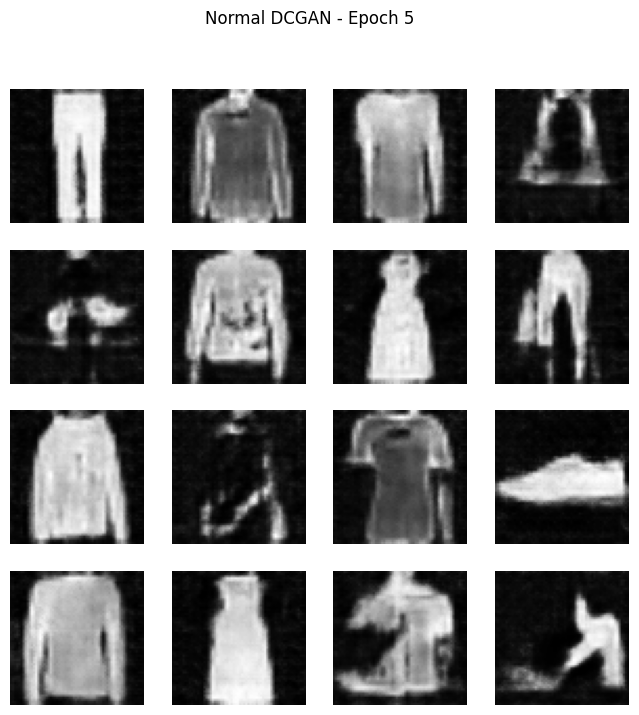

Epoch [6/20] Loss D: 0.1946 Loss G: 2.8873
Epoch [7/20] Loss D: 0.1184 Loss G: 3.1305
Epoch [8/20] Loss D: 0.1032 Loss G: 4.1983
Epoch [9/20] Loss D: 0.1038 Loss G: 4.5170
Epoch [10/20] Loss D: 0.0606 Loss G: 4.2089


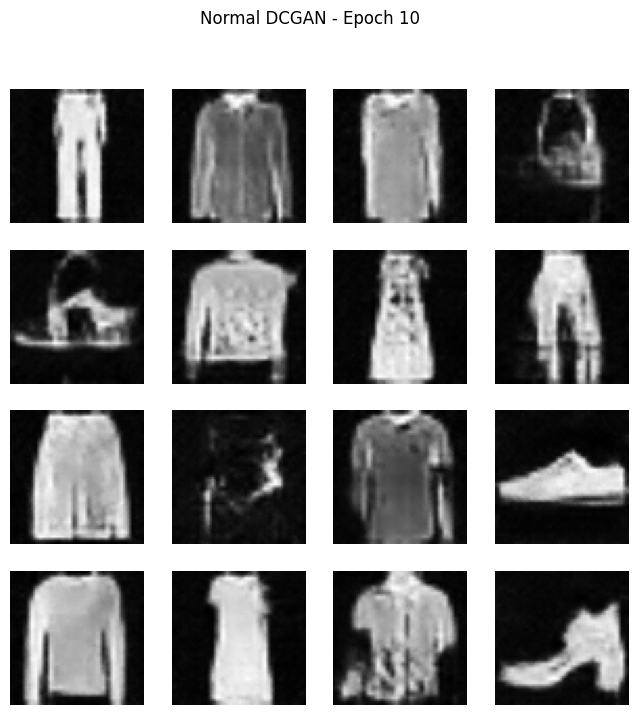

Epoch [11/20] Loss D: 0.2417 Loss G: 4.0499
Epoch [12/20] Loss D: 0.9721 Loss G: 1.2503
Epoch [13/20] Loss D: 0.0221 Loss G: 6.7055
Epoch [14/20] Loss D: 0.0339 Loss G: 4.7819
Epoch [15/20] Loss D: 0.2540 Loss G: 3.5633


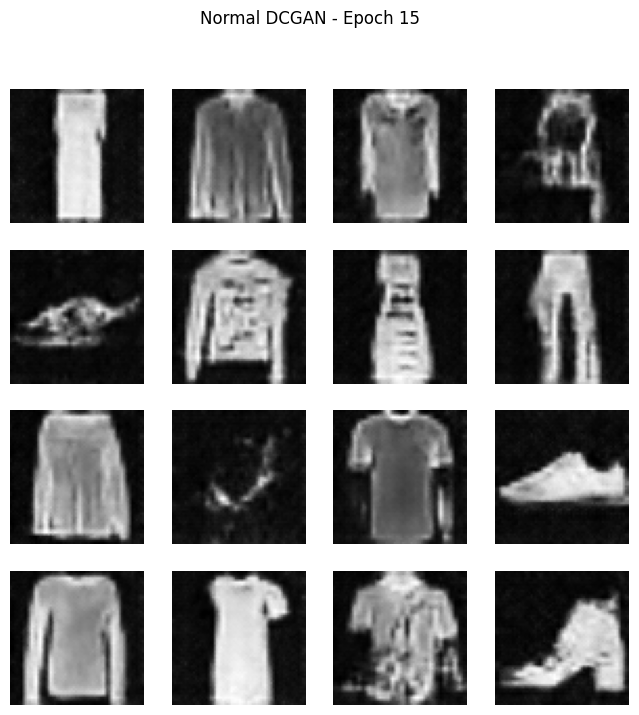

Epoch [16/20] Loss D: 0.8603 Loss G: 2.0412
Epoch [17/20] Loss D: 0.0348 Loss G: 5.0208
Epoch [18/20] Loss D: 0.2351 Loss G: 5.8636
Epoch [19/20] Loss D: 0.0242 Loss G: 6.0700
Epoch [20/20] Loss D: 0.0311 Loss G: 4.7625


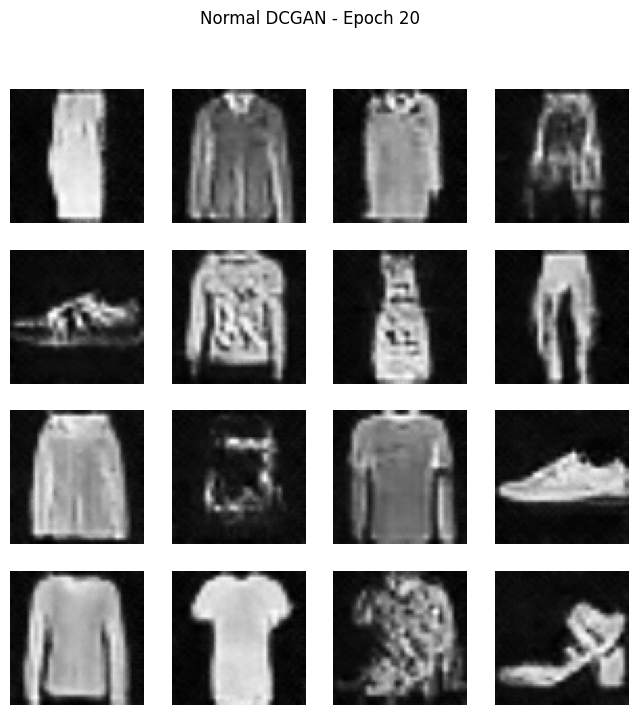

In [11]:
G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size_current = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------

        netD.zero_grad()

        real_labels = torch.ones(batch_size_current, device=device)
        fake_labels = torch.zeros(batch_size_current, device=device)

        output_real = netD(real_images)

        lossD_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size_current, nz, 1, 1, device=device)

        fake_images = netG(noise)

        output_fake = netD(fake_images.detach())

        lossD_fake = criterion(output_fake, fake_labels)

        lossD = lossD_real + lossD_fake

        lossD.backward()
        optimizerD.step()

        # -------------------------
        # Train Generator
        # -------------------------

        netG.zero_grad()

        output = netD(fake_images)

        lossG = criterion(output, real_labels)

        lossG.backward()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss D: {lossD.item():.4f} "
        f"Loss G: {lossG.item():.4f}"
    )

    if (epoch + 1) % 5 == 0:
        show_generated_images(
            netG,
            epoch + 1,
            "Normal DCGAN"
        )

11. Plot training loss

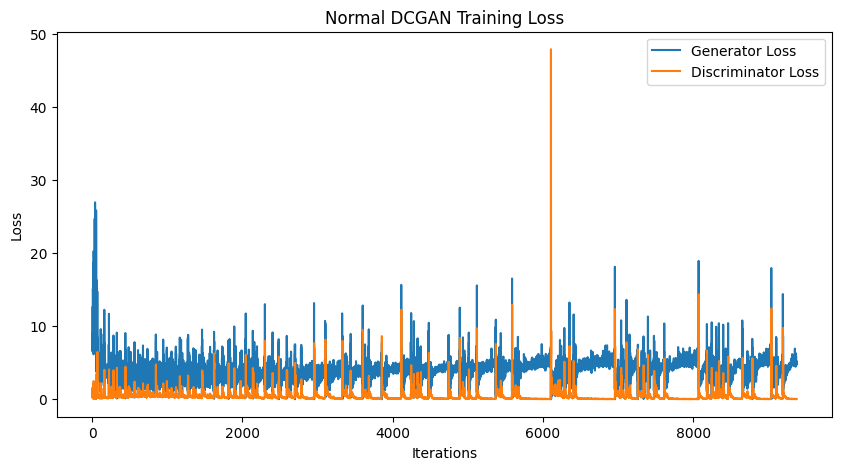

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Normal DCGAN Training Loss")
plt.legend()
plt.show()

#MODE COLLAPSE

12. Define Broken Generator

In [13]:
class BrokenGenerator(nn.Module):

    def __init__(self, nz=100):
        super(BrokenGenerator, self).__init__()

        self.model = nn.Sequential(

            # Reduced capacity
            nn.ConvTranspose2d(nz, 128, 4, 1, 0, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

13.Create broken GAN

In [14]:
brokenG = BrokenGenerator(nz).to(device)
brokenD = Discriminator().to(device)

brokenG.apply(weights_init)
brokenD.apply(weights_init)

criterion_broken = nn.BCELoss()

14. High Learning rate

In [15]:
optimizerD_broken = optim.Adam(
    brokenD.parameters(),
    lr=0.002,
    betas=(0.5, 0.999)
)

optimizerG_broken = optim.Adam(
    brokenG.parameters(),
    lr=0.002,
    betas=(0.5, 0.999)
)

print("Broken GAN learning rate: 0.002")

Broken GAN learning rate: 0.002


15. Train the Broken GAN

Epoch [1/10] Loss D: 1.2735 Loss G: 0.3030
Epoch [2/10] Loss D: 0.4188 Loss G: 3.1455
Epoch [3/10] Loss D: 0.1037 Loss G: 4.0696
Epoch [4/10] Loss D: 0.0003 Loss G: 10.1394
Epoch [5/10] Loss D: 0.0003 Loss G: 8.7514


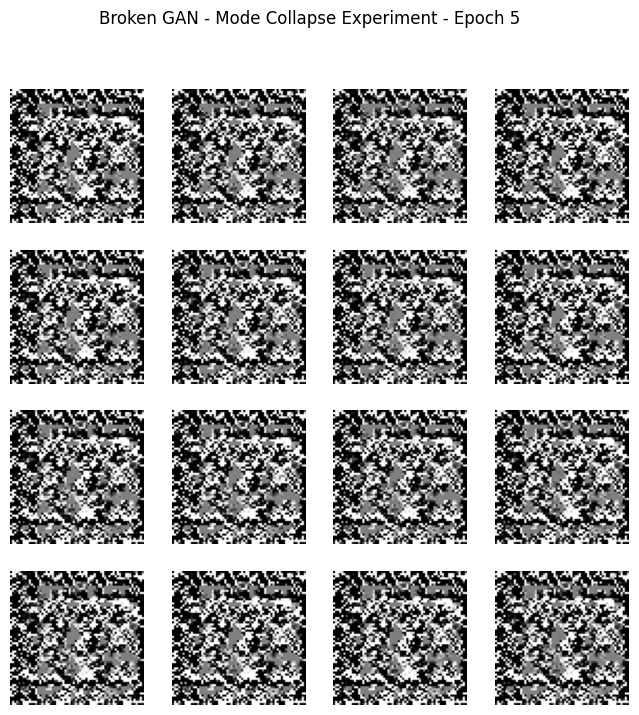

Epoch [6/10] Loss D: 0.0001 Loss G: 10.0923
Epoch [7/10] Loss D: 0.0001 Loss G: 10.3391
Epoch [8/10] Loss D: 0.0000 Loss G: 10.7916
Epoch [9/10] Loss D: 0.0000 Loss G: 11.7552
Epoch [10/10] Loss D: 0.0000 Loss G: 12.0983


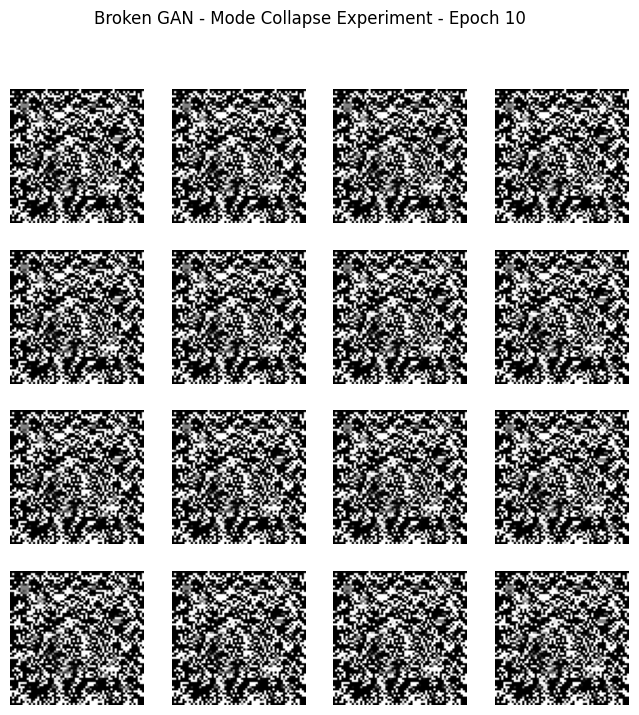

In [17]:
broken_G_losses = []
broken_D_losses = []

broken_epochs = 10

for epoch in range(broken_epochs):

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size_current = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------

        brokenD.zero_grad()

        real_labels = torch.ones(
            batch_size_current,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size_current,
            device=device
        )

        output_real = brokenD(real_images)

        lossD_real = criterion_broken(
            output_real,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            nz,
            1,
            1,
            device=device
        )

        fake_images = brokenG(noise)

        output_fake = brokenD(
            fake_images.detach()
        )

        lossD_fake = criterion_broken(
            output_fake,
            fake_labels
        )

        lossD = lossD_real + lossD_fake

        lossD.backward()
        optimizerD_broken.step()

        # -------------------------
        # Train Generator
        # -------------------------

        brokenG.zero_grad()

        output = brokenD(fake_images)

        lossG = criterion_broken(
            output,
            real_labels
        )

        lossG.backward()
        optimizerG_broken.step()

        broken_G_losses.append(lossG.item())
        broken_D_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{broken_epochs}] "
        f"Loss D: {lossD.item():.4f} "
        f"Loss G: {lossG.item():.4f}"
    )

    if (epoch + 1) % 5 == 0:

        show_generated_images(
            brokenG,
            epoch + 1,
            "Broken GAN - Mode Collapse Experiment"
        )

16. Save the broken output

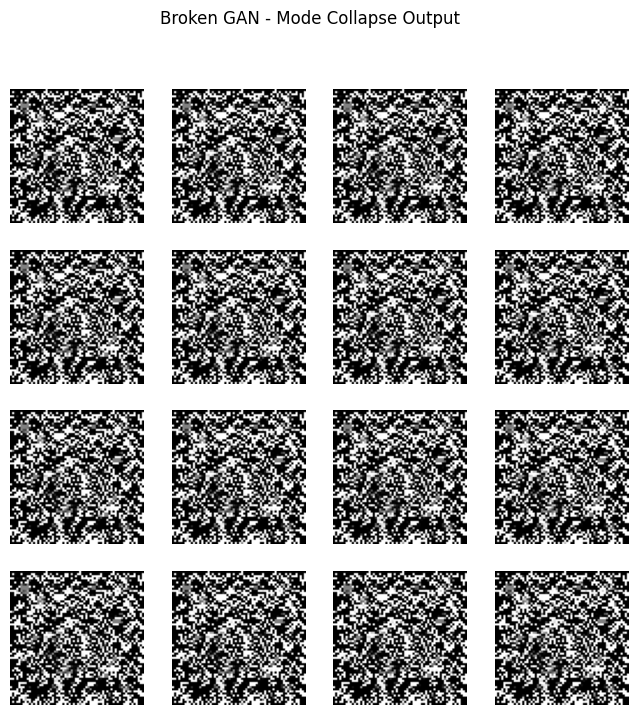

In [18]:
with torch.no_grad():

    collapsed_images = brokenG(
        fixed_noise
    ).detach().cpu()

collapsed_images = (collapsed_images + 1) / 2

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        collapsed_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Broken GAN - Mode Collapse Output")

plt.savefig(
    "mode_collapse_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

17. Create improved Generator and Discriminator

In [19]:
fixedG = Generator(nz).to(device)
fixedD = Discriminator().to(device)

fixedG.apply(weights_init)
fixedD.apply(weights_init)

criterion_fixed = nn.BCELoss()

18. Learning Rate

In [20]:
optimizerD_fixed = optim.Adam(
    fixedD.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizerG_fixed = optim.Adam(
    fixedG.parameters(),
    lr=0.0001,
    betas=(0.5, 0.999)
)

print("Generator learning rate:", 0.0001)
print("Discriminator learning rate:", 0.0002)

Generator learning rate: 0.0001
Discriminator learning rate: 0.0002


19. Train the Improved GAN

Epoch [1/10] Loss D: 0.8666 Loss G: 7.2355
Epoch [2/10] Loss D: 0.1197 Loss G: 3.9749
Epoch [3/10] Loss D: 0.1029 Loss G: 4.5569
Epoch [4/10] Loss D: 1.8552 Loss G: 5.3720
Epoch [5/10] Loss D: 0.3640 Loss G: 4.5809


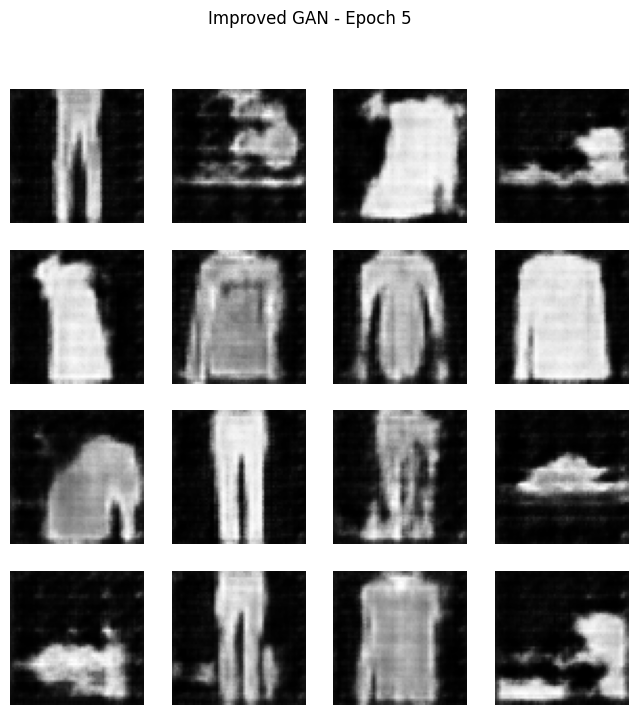

Epoch [6/10] Loss D: 0.0480 Loss G: 4.4105
Epoch [7/10] Loss D: 0.1077 Loss G: 3.9330
Epoch [8/10] Loss D: 0.0576 Loss G: 4.1907
Epoch [9/10] Loss D: 0.1356 Loss G: 6.0778
Epoch [10/10] Loss D: 0.5475 Loss G: 8.7141


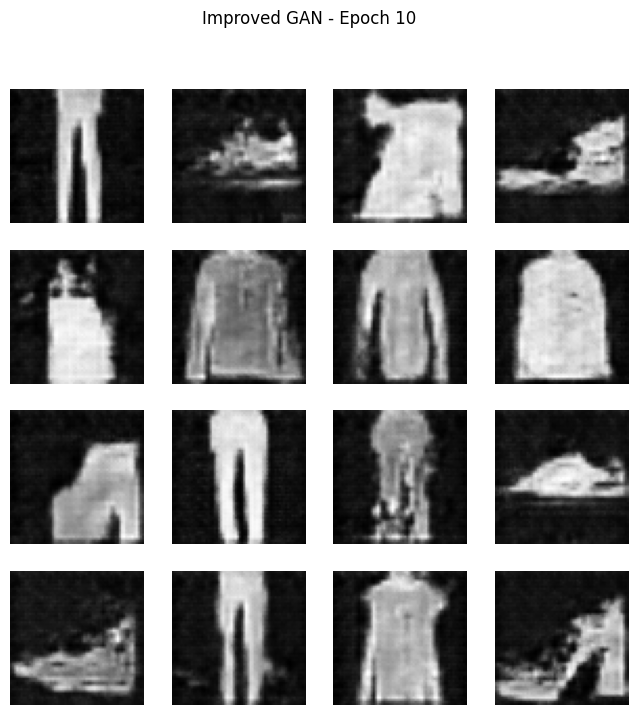

In [22]:
fixed_G_losses = []
fixed_D_losses = []

fixed_epochs = 10

for epoch in range(fixed_epochs):

    for i, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)

        batch_size_current = real_images.size(0)

        real_labels = torch.ones(
            batch_size_current,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size_current,
            device=device
        )

        # =========================
        # Train Discriminator
        # =========================

        fixedD.zero_grad()

        output_real = fixedD(real_images)

        lossD_real = criterion_fixed(
            output_real,
            real_labels
        )

        noise = torch.randn(
            batch_size_current,
            nz,
            1,
            1,
            device=device
        )

        fake_images = fixedG(noise)

        output_fake = fixedD(
            fake_images.detach()
        )

        lossD_fake = criterion_fixed(
            output_fake,
            fake_labels
        )

        lossD = lossD_real + lossD_fake

        lossD.backward()

        optimizerD_fixed.step()

        # =========================
        # Train Generator
        # =========================

        fixedG.zero_grad()

        output = fixedD(fake_images)

        lossG = criterion_fixed(
            output,
            real_labels
        )

        lossG.backward()

        optimizerG_fixed.step()

        fixed_G_losses.append(lossG.item())
        fixed_D_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{fixed_epochs}] "
        f"Loss D: {lossD.item():.4f} "
        f"Loss G: {lossG.item():.4f}"
    )

    if (epoch + 1) % 5 == 0:

        show_generated_images(
            fixedG,
            epoch + 1,
            "Improved GAN"
        )

20. Save the output

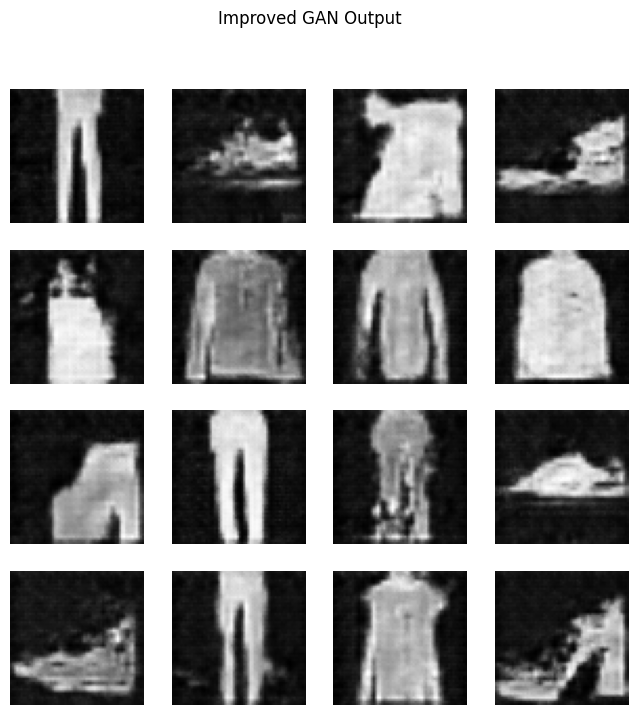

In [23]:
with torch.no_grad():

    improved_images = fixedG(
        fixed_noise
    ).detach().cpu()

improved_images = (improved_images + 1) / 2

plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        improved_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Improved GAN Output")

plt.savefig(
    "improved_gan_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

21. Compare the loss

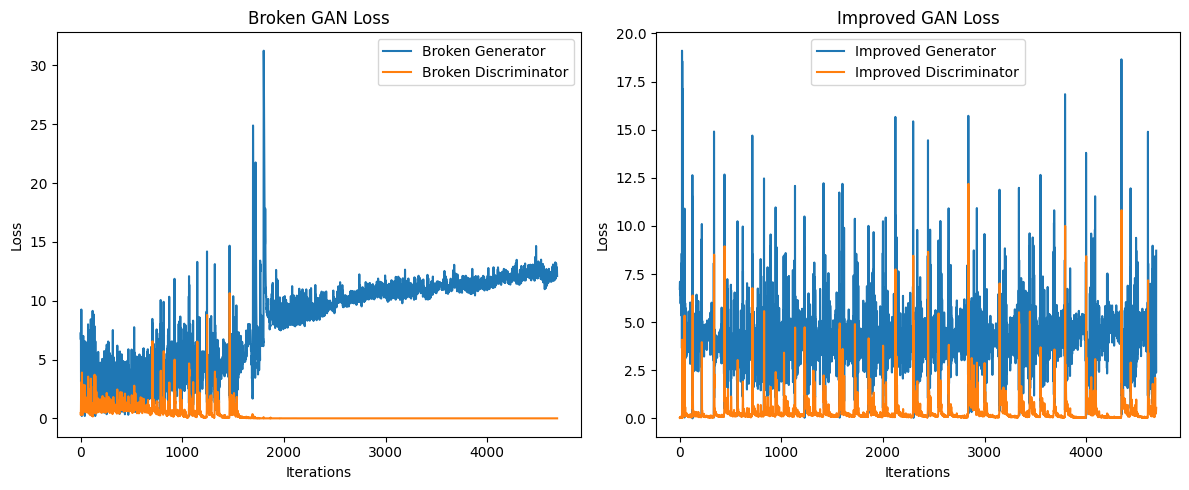

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    broken_G_losses,
    label="Broken Generator"
)

plt.plot(
    broken_D_losses,
    label="Broken Discriminator"
)

plt.title("Broken GAN Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1, 2, 2)

plt.plot(
    fixed_G_losses,
    label="Improved Generator"
)

plt.plot(
    fixed_D_losses,
    label="Improved Discriminator"
)

plt.title("Improved GAN Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

23. Side by Side Comparison

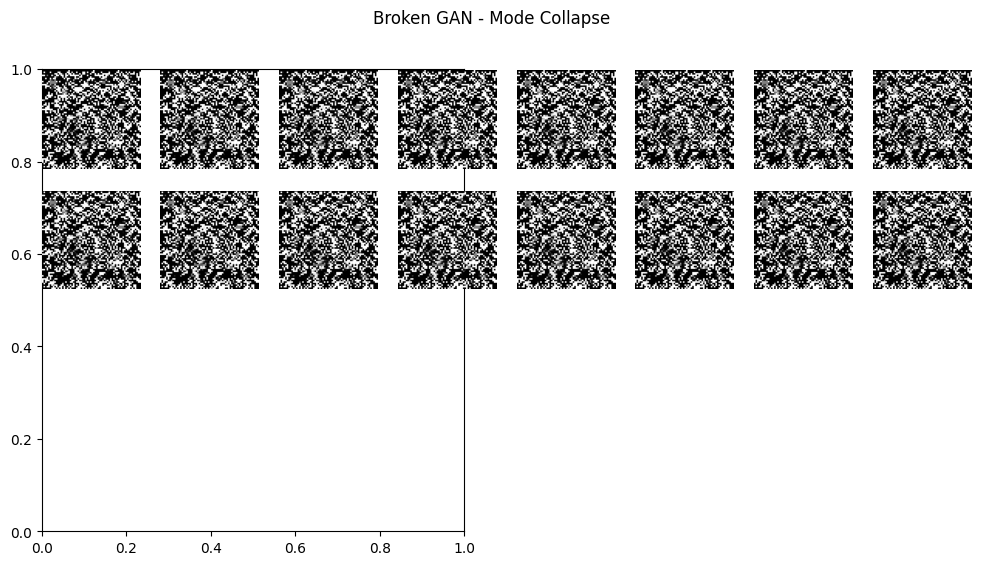

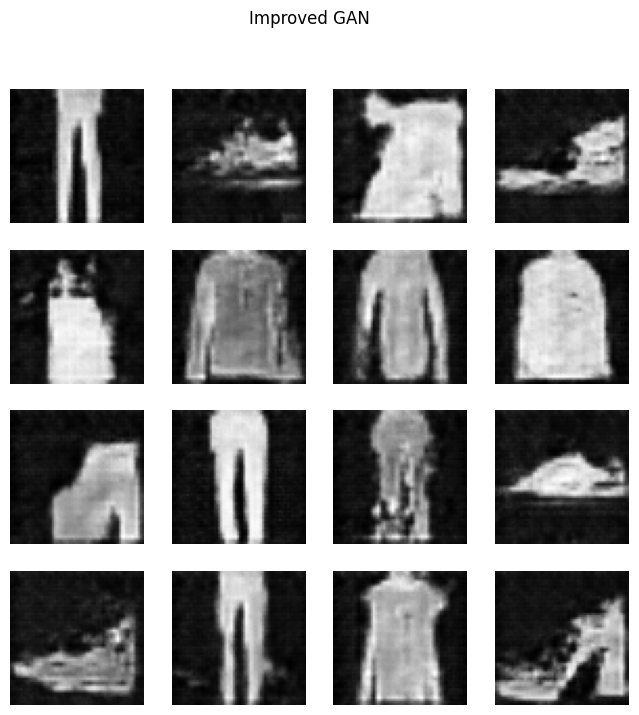

In [25]:
plt.figure(figsize=(12, 6))

# Broken
plt.subplot(1, 2, 1)

for i in range(16):

    plt.subplot(4, 8, i + 1)

    plt.imshow(
        collapsed_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Broken GAN - Mode Collapse")


plt.figure(figsize=(8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        improved_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("Improved GAN")

plt.show()